# Case A : Data only (dt=0.05)

[data] family size: 88
float64
float64

float64
float64

 PHASE 1: Adam 
1 loss 1.1773909201254982
100 loss 0.004140532548110533
200 loss 0.001262621471922342
300 loss 0.0008077787035742744
400 loss 0.0005692579069350096
500 loss 0.0002515365240647221
600 loss 0.00022801840880431047
700 loss 0.0002152315573535903
800 loss 0.0003090976998041546
900 loss 0.0003510939189276328
1000 loss 5.9568733699780506e-05
1100 loss 0.00014317468462618916
1200 loss 3.78956519231108e-05
1300 loss 0.00020966178498131106
1400 loss 0.00019089542966306216
1500 loss 8.693492637454324e-05
1600 loss 0.0001944417687697467
1700 loss 8.046648924396225e-05
1800 loss 0.00021274846312030227
1900 loss 0.00013933794030567706
2000 loss 7.74791545362385e-05

 PHASE 2: L-BFGS 

=== TEST & DIAGNOSTICS ===

--- sin(x) ---
[test] sin(x)       | Residual | L∞=3.637e-03 | Mean=1.103e-03


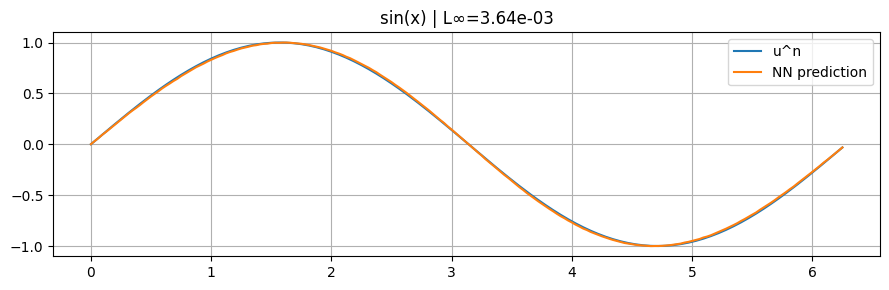

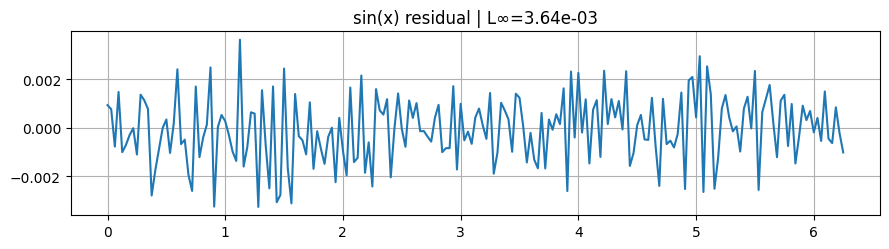

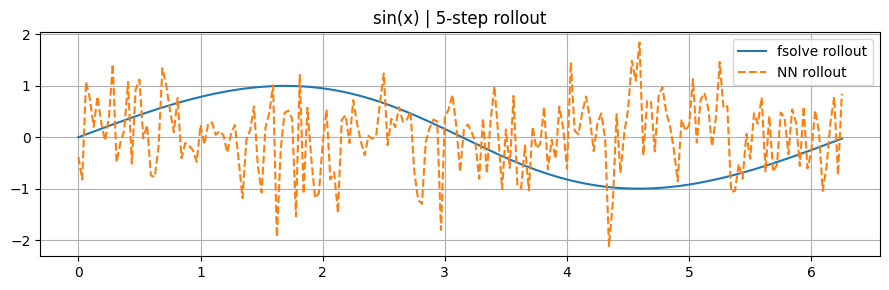


--- cos(14*x) ---
[test] cos(14*x)    | Residual | L∞=3.570e-03 | Mean=9.536e-04


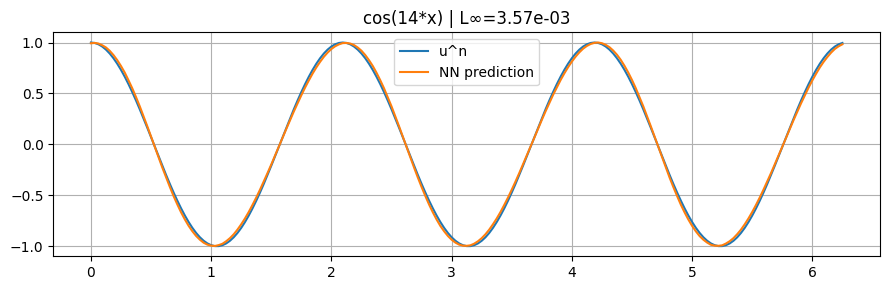

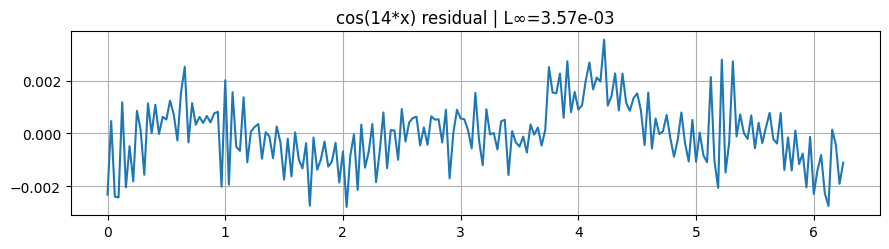

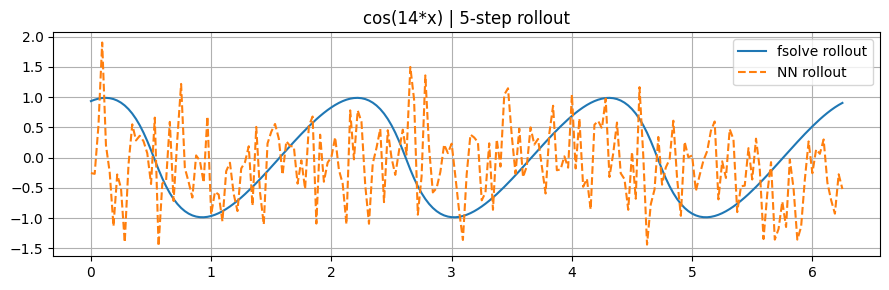


--- sin(x+0.3) ---
[test] sin(x+0.3)   | Residual | L∞=7.452e-03 | Mean=2.317e-03


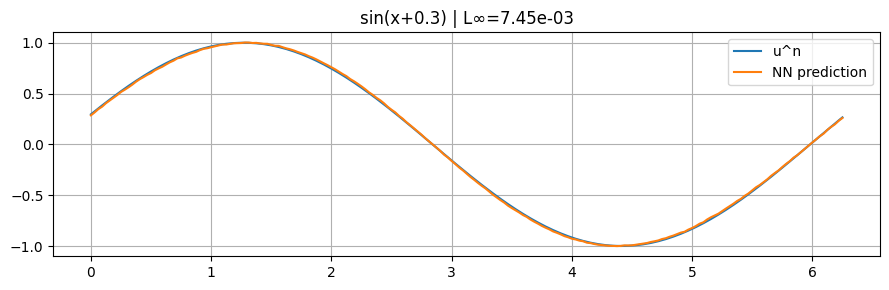

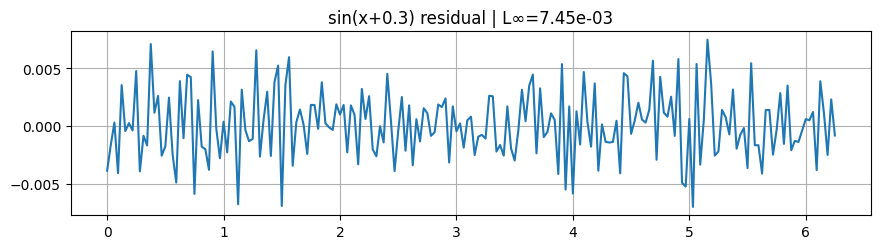

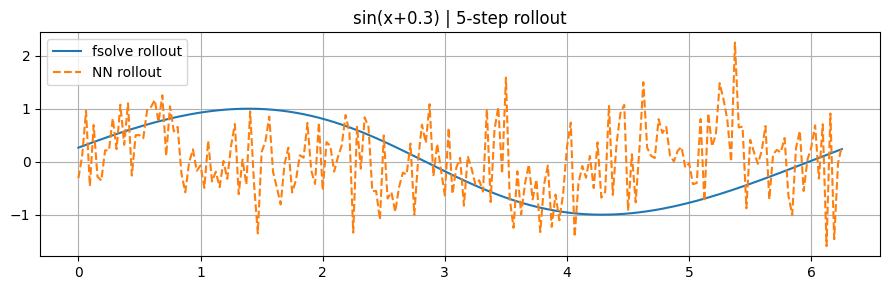


--- sin^2(x) ---
[test] sin^2(x)     | Residual | L∞=1.286e-02 | Mean=3.054e-03


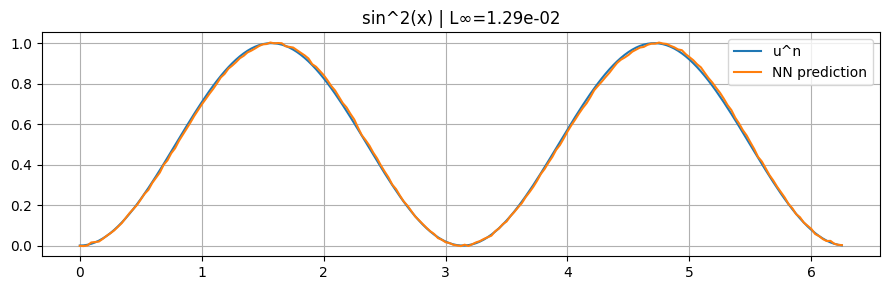

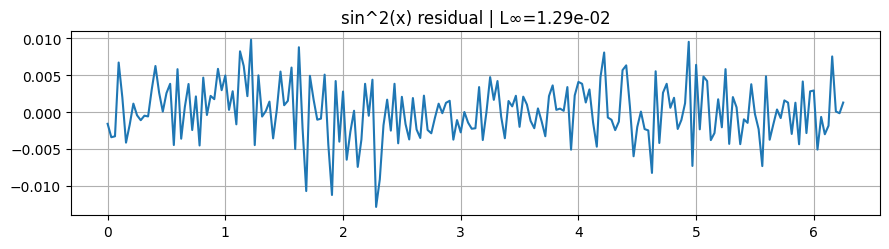

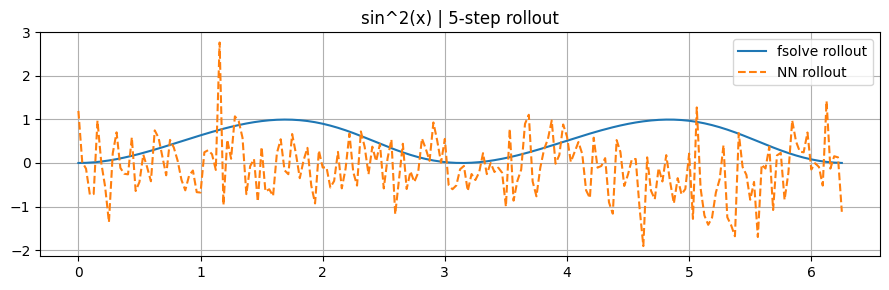


--- cos^3(x) ---
[test] cos^3(x)     | Residual | L∞=3.256e-02 | Mean=6.369e-03


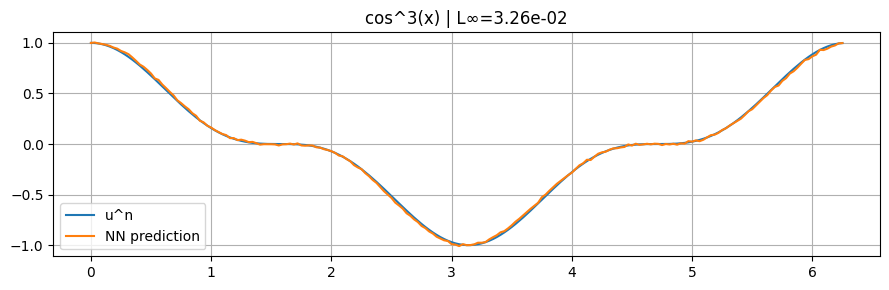

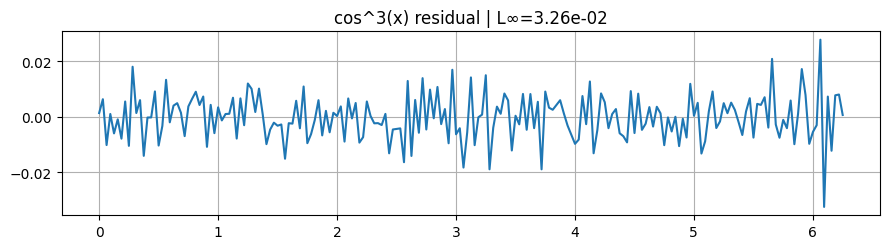

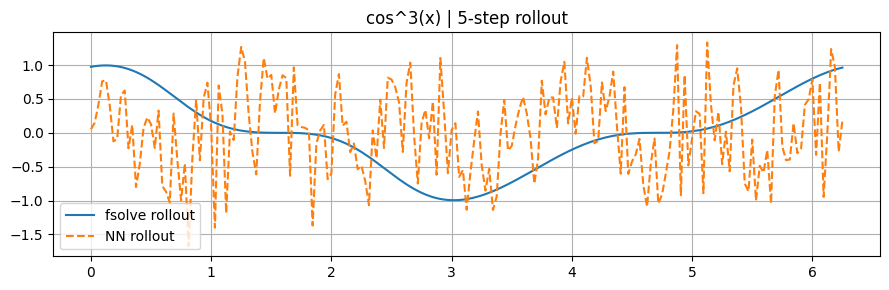


--- sin(2.5x) ---
[test] sin(2.5x)    | Residual | L∞=1.821e-02 | Mean=4.689e-03


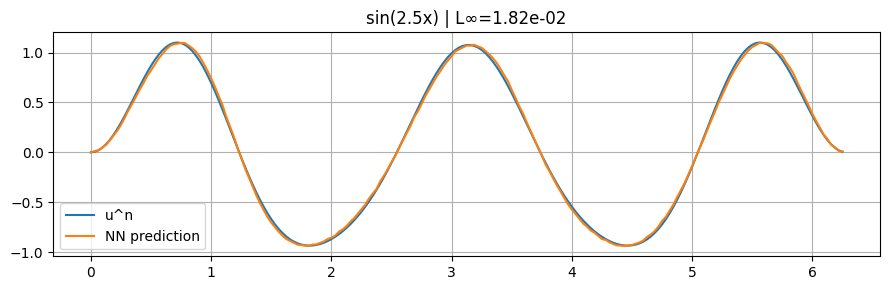

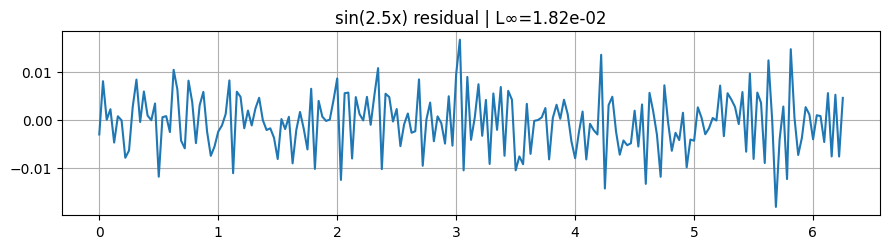

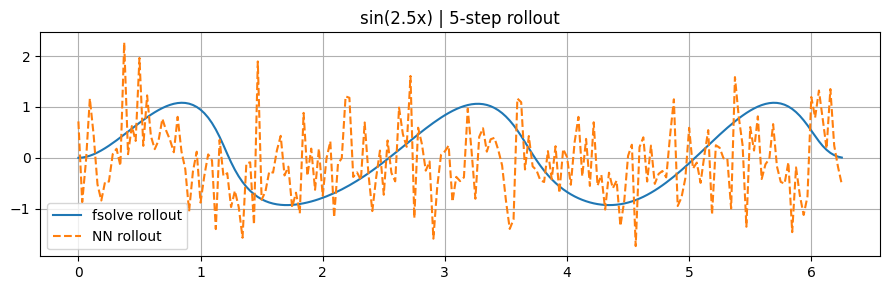


--- sin(x+1.2) ---
[test] sin(x+1.2)   | Residual | L∞=4.254e-02 | Mean=9.903e-03


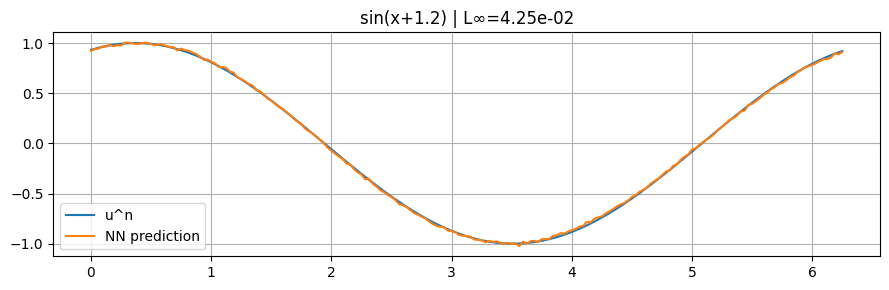

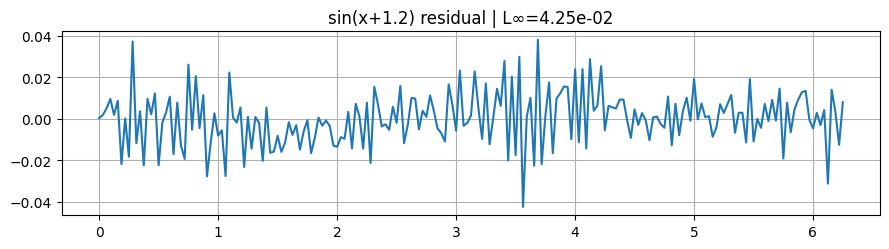

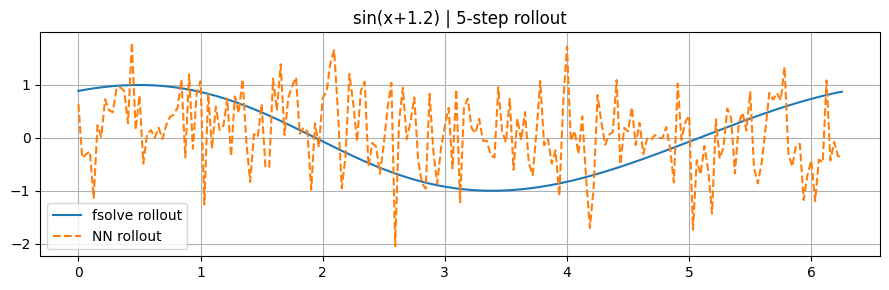


DONE.


In [1]:
import os, warnings, random
import numpy as np
import tensorflow as tf
from scipy.optimize import fsolve, minimize
import matplotlib.pyplot as plt

tf.config.set_visible_devices([], 'GPU')

# CONFIG

NX_COARSE = 11
NX_FINE   = 201
L = 2*np.pi
DT = 0.05

USE_SIREN    = True
SIREN_W0     = 15.0
HIDDEN_UNITS = 512
DEPTH        = 5

EPOCHS = 2500
LR = 5e-5
GRAD_CLIP = 1.0
PATIENCE = 800

USE_LBFGS = True
LBFGS_MAXITER = 50
LBFGS_MAXCOR = 3
N_LBFGS = 25

OUT_DIR="pinn_caseA_data_only"
os.makedirs(OUT_DIR,exist_ok=True)

WEIGHTS_FILE=os.path.join(OUT_DIR,"nn_caseA.weights.h5")
DATA_FILE=os.path.join(OUT_DIR,"train_pairs_caseA_v2.npz")  #  FIX

tf.keras.backend.set_floatx("float64")

np.random.seed(42); tf.random.set_seed(42); random.seed(42)


# Spectral differentiation matrix

def generate_D_matrix(Nx,L):
    k=2*np.pi*1j*np.fft.fftfreq(Nx,d=L/Nx)
    I=np.eye(Nx)
    return np.fft.ifft(k[:,None]*np.fft.fft(I,axis=0),axis=0).real.astype(np.float64)

D_np=generate_D_matrix(NX_FINE,L)

# grids
x_coarse=np.linspace(0,L,NX_COARSE,endpoint=False)
x_fine=np.linspace(0,L,NX_FINE,endpoint=False)

def fourier_interpolate(u,Nc,Nf):
    U=np.fft.fftshift(np.fft.fft(u))
    pad=Nf-Nc
    U=np.pad(U,(pad//2,pad-pad//2))
    return (np.fft.ifft(np.fft.ifftshift(U))*Nf/Nc).real.astype(np.float64)


# fsolve

def compute_y1_fsolve(un):
    def F(y): return y-un+0.25*DT*(D_np@(y**2))
    def J(y): return np.eye(len(un))+0.5*DT*(D_np@np.diag(y))
    y,_ ,_,_=fsolve(F,un,fprime=J,xtol=1e-10,maxfev=20000,full_output=True)
    return y.astype(np.float64)


# training funct un
def make_rich_family():
    fns = []
    for k in range(1, 13):
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
        fns.append((f"cos({k}x)", lambda x, kk=k: np.cos(kk*x)))

    # phase shifted
    for k in range(1, 6):
        for phi in [0.3, 0.7, 1.2]:
            fns.append((f"sin({k}x+{phi})",
                        lambda x, kk=k, pp=phi: np.sin(kk*x + pp)))

    # fractional freq
    for k in [1.5, 2.5, 3.5, 4.5]:
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
    # polynomial type nonlinearities
    fns += [
        ("sin^2(x)"     , lambda x: np.sin(x)**2),
        ("cos^2(x)"     , lambda x: np.cos(x)**2),
        ("sin^3(x)"     , lambda x: np.sin(x)**3),
        ("cos^3(x)"     , lambda x: np.cos(x)**3),
    ]
    
    # mixed modes
    fns += [
        ("sin+0.5sin2", lambda x: np.sin(x)+0.5*np.sin(2*x)),
        ("cos+0.5cos2", lambda x: np.cos(x)+0.5*np.cos(2*x)),
        ("sin2+cos3"  , lambda x: np.sin(2*x)+np.cos(3*x)),
        ("sin3+cos5"  , lambda x: np.sin(3*x)+0.7*np.cos(5*x)),
        ("sin5+sin7"  , lambda x: 0.6*np.sin(5*x)+0.4*np.sin(7*x)),
        ("cos4+cos8"  , lambda x: 0.5*np.cos(4*x)+0.5*np.cos(8*x)),
    ]
    # Gaussians times sines/cosines
    fns += [
        ("gauss*sin(5x)",  lambda x: np.exp(-(x-np.pi)**2)*np.sin(5*x)),
        ("gauss*sin(10x)", lambda x: np.exp(-(x-np.pi)**2)*np.sin(10*x)),
        ("gauss*cos(7x)",  lambda x: np.exp(-0.5*(x-np.pi)**2)*np.cos(7*x)),
    ]
    # exponentials & combinations
    fns += [
        ("exp(-x)sin(x)",  lambda x: np.exp(-0.2*x)*np.sin(x)),
        ("exp(-x)cos(3x)", lambda x: np.exp(-0.4*x)*np.cos(3*x)),
    ]

    # random linear combos of sines/cosines for more variety
    rng = np.random.default_rng(123)
    for idx in range(30):   
        ks  = rng.integers(1, 13, size=3)
        a   = rng.uniform(-1.0, 1.0, size=3)
        b   = rng.uniform(-1.0, 1.0, size=3)
        def make_fn(ks=ks, a=a, b=b):
            return lambda x, ks=ks, a=a, b=b: (
                a[0]*np.sin(ks[0]*x) + a[1]*np.cos(ks[1]*x) + a[2]*np.sin(ks[2]*x)
                + b[0]*np.cos(ks[0]*x) + b[1]*np.sin(ks[1]*x) + b[2]*np.cos(ks[2]*x)
            )
        fns.append((f"rand_combo_{idx}", make_fn()))
    return fns

train_fns=make_rich_family()
print("[data] family size:",len(train_fns))


# DATA
if os.path.exists(DATA_FILE):
    d=np.load(DATA_FILE)
    un_train=d["un"]; y1_train=d["y1"]
    un_train = un_train.astype(np.float64)
    y1_train = y1_train.astype(np.float64)
else:
    U=[]; Y=[]
    for _,fn in train_fns:
        uc=fn(x_coarse)
        uf=fourier_interpolate(uc,NX_COARSE,NX_FINE)
        U.append(uf); Y.append(compute_y1_fsolve(uf))
    un_train=np.array(U,dtype=np.float64)
    y1_train=np.array(Y,dtype=np.float64)
    np.savez(DATA_FILE,un=un_train,y1=y1_train)

# FEATURES

def build_features(u):
    mag=np.abs(np.fft.fft(u,axis=-1))[:,:NX_FINE//2+1]
    mag = 0.2 * mag   # FIX
    return np.concatenate([u,mag],axis=-1).astype(np.float64)

X=build_features(un_train)
feat_mean=X.mean(0); feat_std=X.std(0)+1e-12
Xn=(X-feat_mean)/feat_std
Xn = Xn.astype(np.float64)


print(Xn.dtype)
print(y1_train.dtype)

# MODEL

class SineDense(tf.keras.layers.Layer):
    def __init__(self,u,w0=30,is_first=False):
        super().__init__(dtype=tf.float64)
        self.u=u; self.w0=w0; self.f=is_first
    def build(self,s):
        d=int(s[-1])
        b=(1/d) if self.f else np.sqrt(6/d)/self.w0
        self.W=self.add_weight(shape=(d,self.u),
            initializer=tf.keras.initializers.RandomUniform(minval=-b, maxval=b), dtype=tf.float64
)
        self.b=self.add_weight(shape=(self.u,),initializer="zeros")
    def call(self,x): return tf.sin(self.w0*(x@self.W+self.b))

def build_model():
    i = tf.keras.Input(shape=(Xn.shape[1],), dtype=tf.float64)
    h=SineDense(HIDDEN_UNITS,SIREN_W0,True)(i)
    for _ in range(DEPTH-1): h=SineDense(HIDDEN_UNITS,SIREN_W0)(h)
    o=tf.keras.layers.Dense(NX_FINE, dtype=tf.float64)(h)
    return tf.keras.Model(i,o)

model=build_model()

print(model.dtype)
print(model.trainable_variables[0].dtype)


Xtf=tf.constant(Xn, dtype=tf.float64)
Ytf=tf.constant(y1_train, dtype=tf.float64)

opt=tf.keras.optimizers.Adam(LR)


# TRAIN

print("\n PHASE 1: Adam ")

best=np.inf; wait=0

for e in range(1,EPOCHS+1):
    with tf.GradientTape() as t:
        yp=model(Xtf,training=True)
        loss=tf.reduce_mean(tf.square(yp-Ytf))
    g=t.gradient(loss,model.trainable_variables)
    g=[tf.clip_by_norm(x,GRAD_CLIP) for x in g]
    opt.apply_gradients(zip(g,model.trainable_variables))

    if e%100==0 or e==1:
        print(e,"loss",float(loss))

    if float(loss)<best:
        best=float(loss); wait=0; model.save_weights(WEIGHTS_FILE)
    else:
        wait+=1
        if wait>PATIENCE: break


# L-BFGS

if USE_LBFGS:

    print("\n PHASE 2: L-BFGS ")

    model.load_weights(WEIGHTS_FILE)

    X_lbfgs = Xtf[:N_LBFGS]
    Y_lbfgs = Ytf[:N_LBFGS]

    vars = model.trainable_variables
    shapes = [v.shape for v in vars]
    sizes = [int(np.prod(s)) for s in shapes]

    def pack():
        return np.concatenate([v.numpy().ravel() for v in vars])

    def unpack(theta):
        k = 0
        for v, s, sz in zip(vars, shapes, sizes):
            v.assign(theta[k:k+sz].reshape(s))
            k += sz

    @tf.function
    def loss_and_grad():
        with tf.GradientTape() as tape:
            yp = model(X_lbfgs, training=True)
            loss = tf.reduce_mean(tf.square(yp - Y_lbfgs))
        grads = tape.gradient(loss, vars)
        return loss, grads

    def obj(theta):
        unpack(theta)
        loss, grads = loss_and_grad()
        grad_flat = np.concatenate([g.numpy().ravel() for g in grads])
        return float(loss.numpy()), grad_flat

    res = minimize(obj, pack(), jac=True, method="L-BFGS-B",
                   options={"maxiter": LBFGS_MAXITER,"maxcor": LBFGS_MAXCOR})

    unpack(res.x)
    model.save_weights(WEIGHTS_FILE)

# TEST
print("\n TEST & DIAGNOSTICS")

def build_feat_single(u_f):
    mag = np.abs(np.fft.fft(u_f))[:NX_FINE//2+1]
    mag = 0.2 * mag
    feats = np.concatenate([u_f, mag])
    return ((feats - feat_mean) / feat_std)[None, :]

def rollout_nn(u0, steps=5):
    u = u0.copy()
    traj = [u.copy()]
    for _ in range(steps):
        feat = build_feat_single(u)
        y = model(tf.constant(feat, dtype=tf.float64))[0].numpy()   # ✅ FIXED dtype
        u = y.copy()
        traj.append(u.copy())
    return traj

def residual_np(y, u):
    return y - u + 0.25*DT*(D_np @ (y**2))


tests = [
("sin(x)", lambda x: np.sin(x)),
("cos(14*x)", lambda x: np.cos(14*x)),
("sin(x+0.3)", lambda x: np.sin(x+0.3)),
("sin^2(x)", lambda x: np.sin(x)**2),
("cos^3(x)", lambda x: np.cos(x)**3),
("sin(2.5x)", lambda x: np.sin(2.5*x)),
("sin(x+1.2)", lambda x: np.sin(x+1.2))
]

for name, fn in tests:

    print("\n---", name, "---")

    uf = fourier_interpolate(fn(x_coarse), NX_COARSE, NX_FINE)

    feat = build_feat_single(uf)
    y_pred = model(tf.constant(feat, dtype=tf.float64))[0].numpy()  # 

    r = residual_np(y_pred, uf)
    Linf = float(np.max(np.abs(r)))
    Mean = float(np.mean(np.abs(r)))

    print(f"[test] {name:12s} | Residual | L∞={Linf:.3e} | Mean={Mean:.3e}")

    xs = x_fine

    # Sol plot
    plt.figure(figsize=(9,3))
    plt.plot(xs, uf, label="u^n")
    plt.plot(xs, y_pred, label="NN prediction")
    plt.title(f"{name} | L∞={Linf:.2e}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()   
    plt.show()

    # Residual plot
    plt.figure(figsize=(9,2.6))
    plt.plot(xs, r)
    plt.title(f"{name} residual | L∞={Linf:.2e}")
    plt.grid(True)
    plt.tight_layout()   
    plt.show()

    # Rollout
    steps = 5
    traj_nn = rollout_nn(uf, steps)

    traj_fs = [uf.copy()]
    tmp = uf.copy()
    for _ in range(steps):
        tmp = compute_y1_fsolve(tmp)
        traj_fs.append(tmp.copy())

    plt.figure(figsize=(9,3))
    plt.plot(xs, traj_fs[-1], label="fsolve rollout")
    plt.plot(xs, traj_nn[-1], "--", label="NN rollout")

    plt.title(f"{name} | {steps}-step rollout")

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\nDONE.")

# Case A : Data only (dt=0.005)

[data] family size: 88
float64
float64

float64
float64

 PHASE 1: Adam 
1 loss 1.1773909201254982
100 loss 0.004140532548110533
200 loss 0.001262621471922342
300 loss 0.0008077787035742744
400 loss 0.0005692579069350096
500 loss 0.0002515365240647221
600 loss 0.00022801840880431047
700 loss 0.0002152315573535903
800 loss 0.0003090976998041546
900 loss 0.0003510939189276328
1000 loss 5.9568733699780506e-05
1100 loss 0.00014317468462618916
1200 loss 3.78956519231108e-05
1300 loss 0.00020966178498131106
1400 loss 0.00019089542966306216
1500 loss 8.693492637454324e-05
1600 loss 0.0001944417687697467
1700 loss 8.046648924396225e-05
1800 loss 0.00021274846312030227
1900 loss 0.00013933794030567706
2000 loss 7.74791545362385e-05

 PHASE 2: L-BFGS 

=== TEST & DIAGNOSTICS ===

--- sin(x) ---
[test] sin(x)       | Residual | L∞=1.386e-02 | Mean=7.235e-03


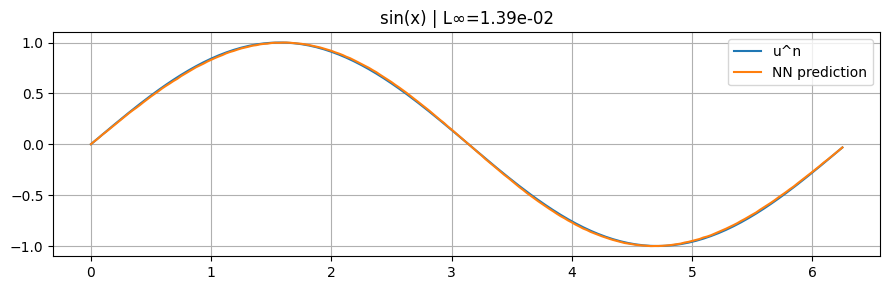

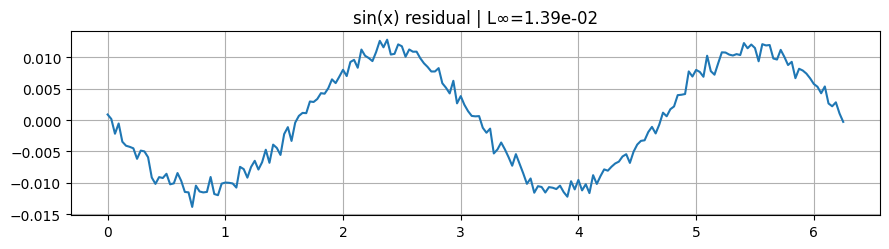

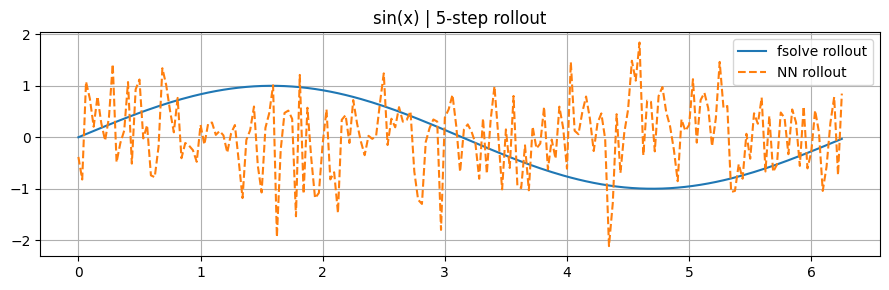


--- cos(14*x) ---
[test] cos(14*x)    | Residual | L∞=3.670e-02 | Mean=2.141e-02


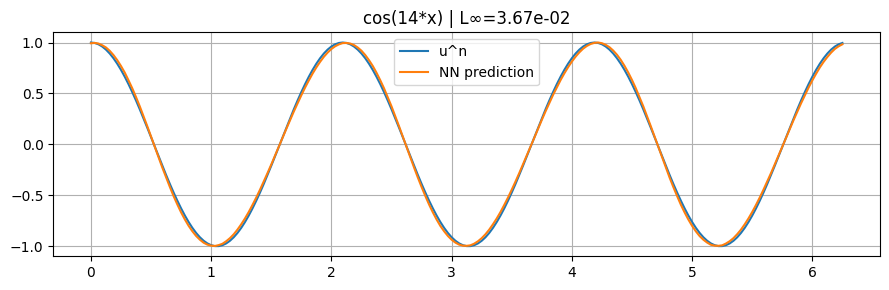

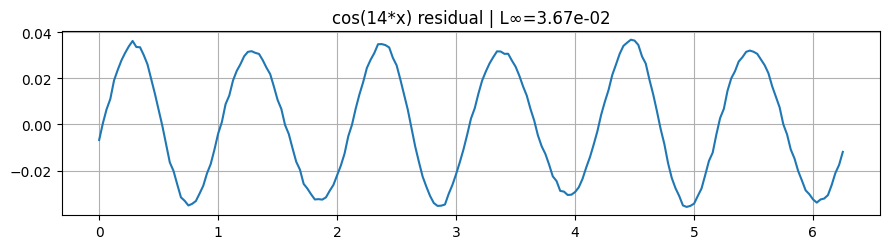

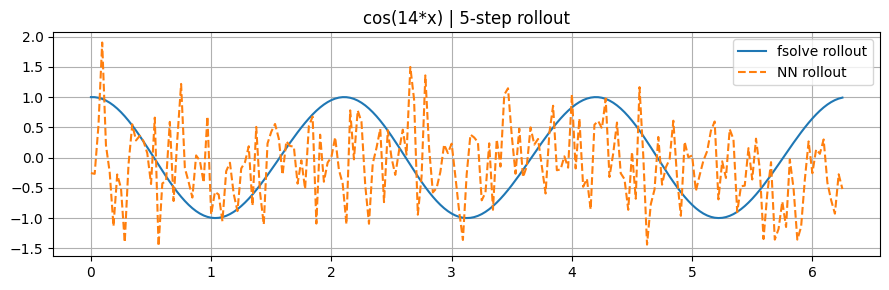


--- sin(x+0.3) ---
[test] sin(x+0.3)   | Residual | L∞=1.642e-02 | Mean=7.419e-03


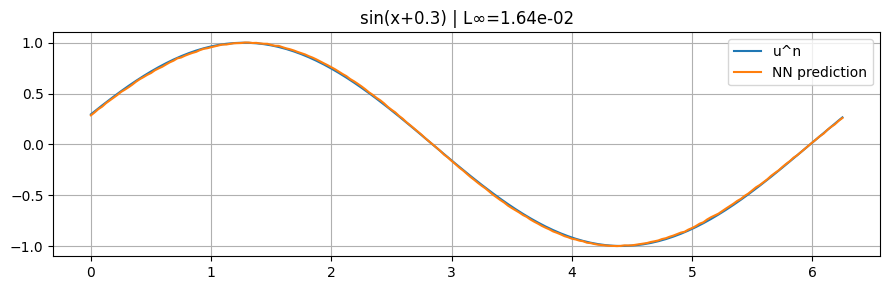

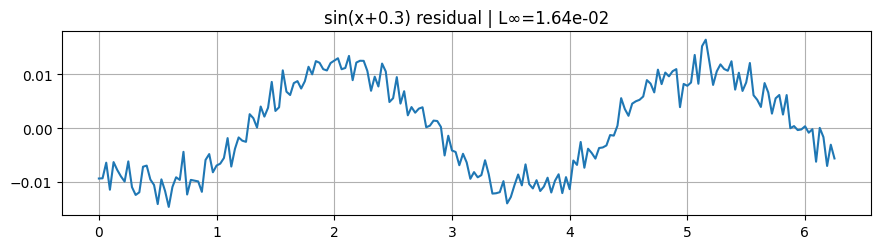

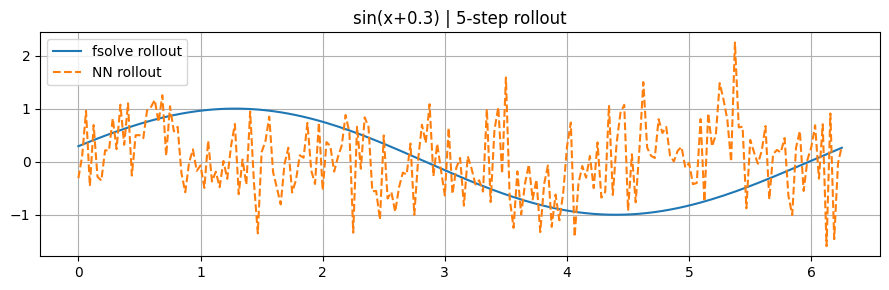


--- sin^2(x) ---
[test] sin^2(x)     | Residual | L∞=1.836e-02 | Mean=7.056e-03


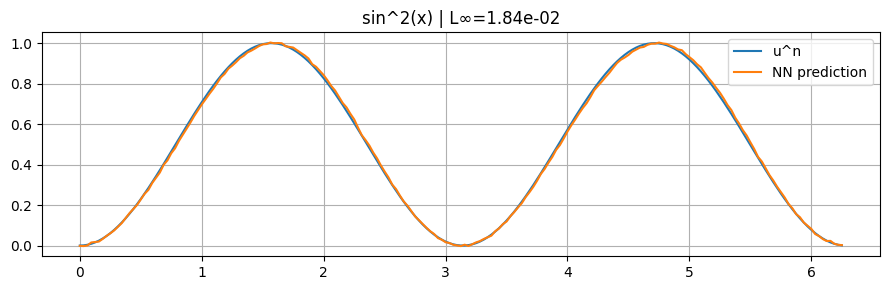

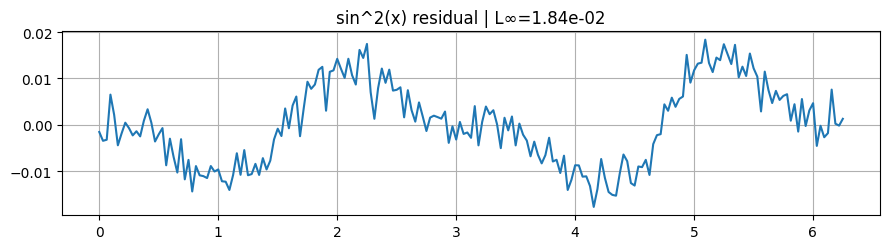

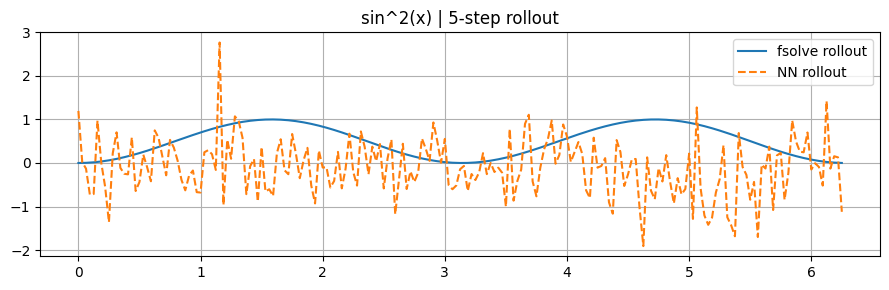


--- cos^3(x) ---
[test] cos^3(x)     | Residual | L∞=2.707e-02 | Mean=9.320e-03


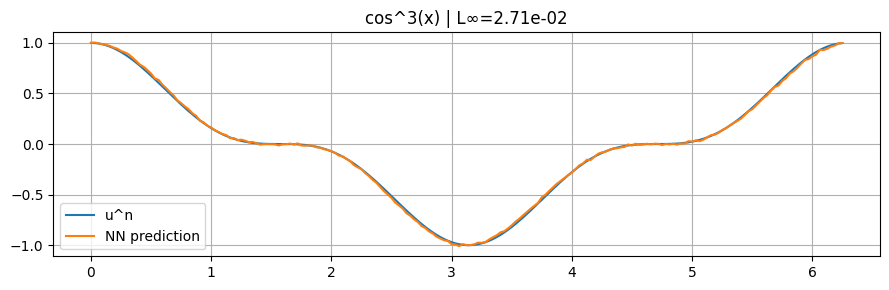

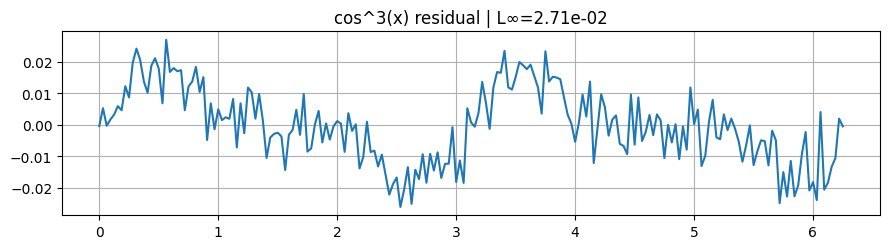

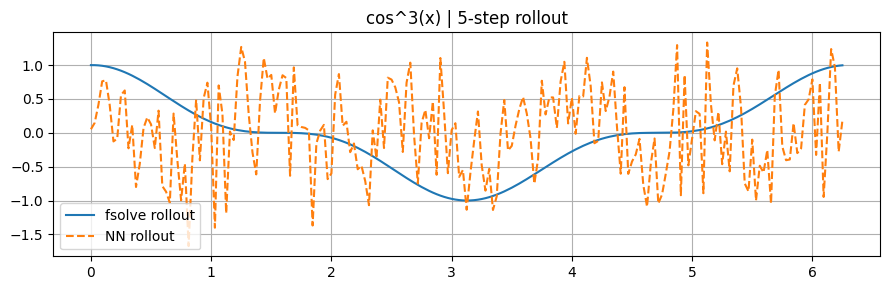


--- sin(2.5x) ---
[test] sin(2.5x)    | Residual | L∞=4.682e-02 | Mean=1.912e-02


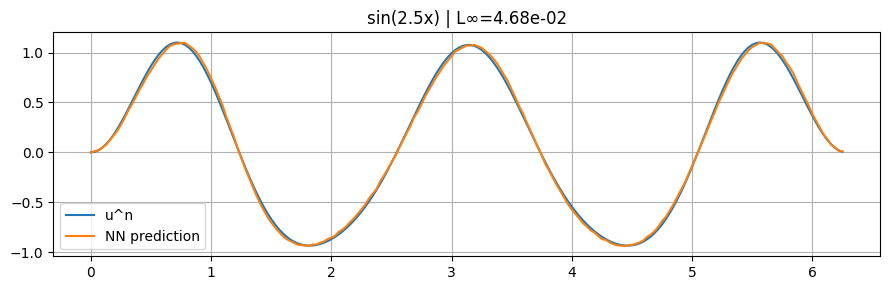

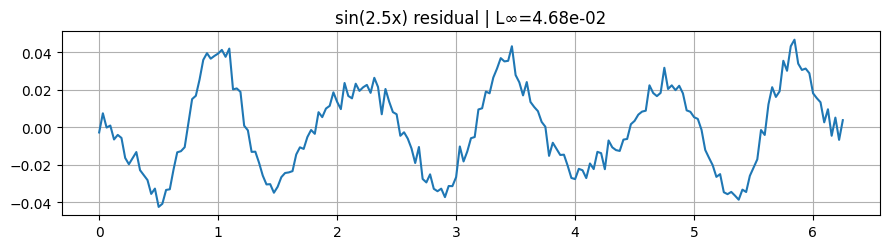

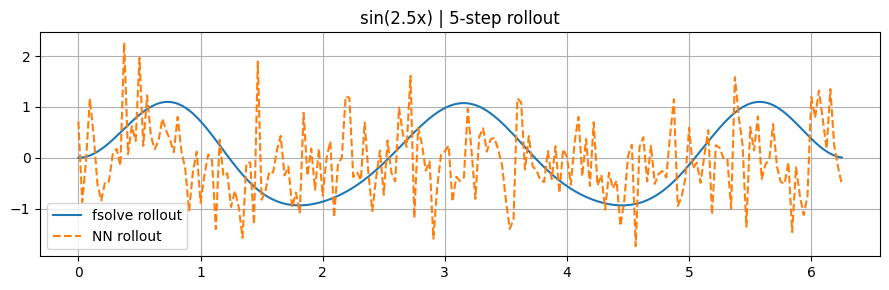


--- sin(x+1.2) ---
[test] sin(x+1.2)   | Residual | L∞=3.414e-02 | Mean=9.236e-03


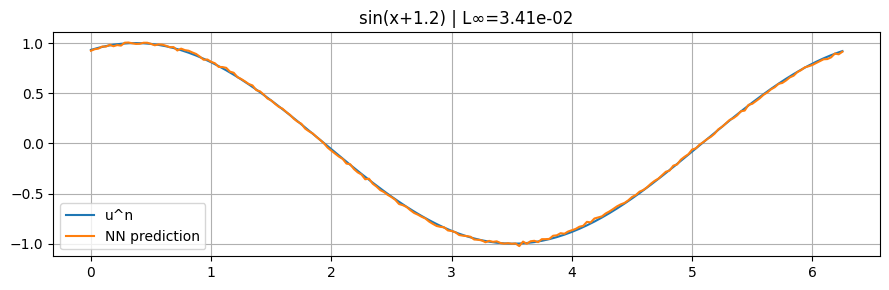

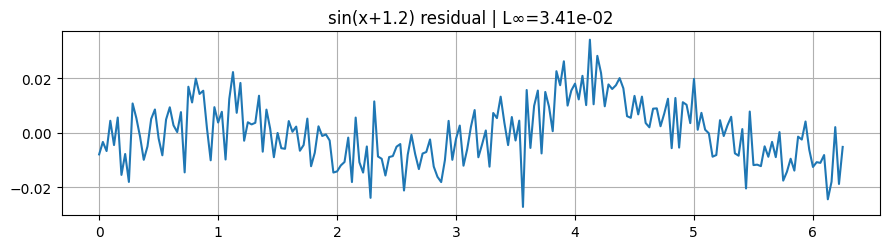

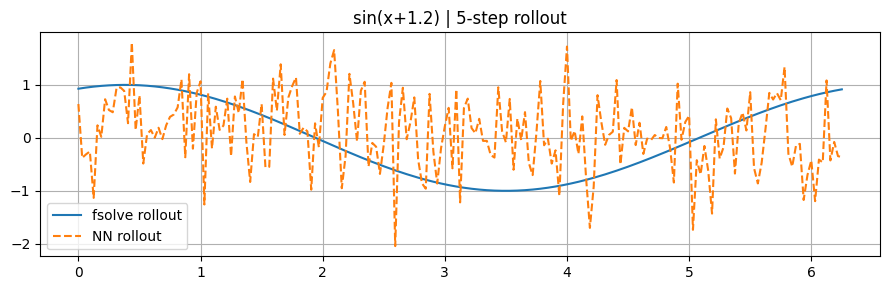


DONE.


In [1]:
import os, warnings, random
import numpy as np
import tensorflow as tf
from scipy.optimize import fsolve, minimize
import matplotlib.pyplot as plt

tf.config.set_visible_devices([], 'GPU')

# CONFIG

NX_COARSE = 11
NX_FINE   = 201
L = 2*np.pi
DT = 0.005

USE_SIREN    = True
SIREN_W0     = 15.0
HIDDEN_UNITS = 512
DEPTH        = 5

EPOCHS = 2500
LR = 5e-5
GRAD_CLIP = 1.0
PATIENCE = 800

USE_LBFGS = True
LBFGS_MAXITER = 50
LBFGS_MAXCOR = 3
N_LBFGS = 25

OUT_DIR="pinn_caseA_data_only"
os.makedirs(OUT_DIR,exist_ok=True)

WEIGHTS_FILE=os.path.join(OUT_DIR,"nn_caseA.weights.h5")
DATA_FILE=os.path.join(OUT_DIR,"train_pairs_caseA_v2.npz")  #  FIX

tf.keras.backend.set_floatx("float64")

np.random.seed(42); tf.random.set_seed(42); random.seed(42)


# Spectral differentiation matrix

def generate_D_matrix(Nx,L):
    k=2*np.pi*1j*np.fft.fftfreq(Nx,d=L/Nx)
    I=np.eye(Nx)
    return np.fft.ifft(k[:,None]*np.fft.fft(I,axis=0),axis=0).real.astype(np.float64)

D_np=generate_D_matrix(NX_FINE,L)

# grids
x_coarse=np.linspace(0,L,NX_COARSE,endpoint=False)
x_fine=np.linspace(0,L,NX_FINE,endpoint=False)

def fourier_interpolate(u,Nc,Nf):
    U=np.fft.fftshift(np.fft.fft(u))
    pad=Nf-Nc
    U=np.pad(U,(pad//2,pad-pad//2))
    return (np.fft.ifft(np.fft.ifftshift(U))*Nf/Nc).real.astype(np.float64)


# fsolve

def compute_y1_fsolve(un):
    def F(y): return y-un+0.25*DT*(D_np@(y**2))
    def J(y): return np.eye(len(un))+0.5*DT*(D_np@np.diag(y))
    y,_ ,_,_=fsolve(F,un,fprime=J,xtol=1e-10,maxfev=20000,full_output=True)
    return y.astype(np.float64)

# training funct un
def make_rich_family():
    fns = []
    
    for k in range(1, 13):
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
        fns.append((f"cos({k}x)", lambda x, kk=k: np.cos(kk*x)))

    # phase shifted
    for k in range(1, 6):
        for phi in [0.3, 0.7, 1.2]:
            fns.append((f"sin({k}x+{phi})",
                        lambda x, kk=k, pp=phi: np.sin(kk*x + pp)))

    # fractional freq
    for k in [1.5, 2.5, 3.5, 4.5]:
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
    # polynomial-type nonlinearities
    fns += [
        ("sin^2(x)"     , lambda x: np.sin(x)**2),
        ("cos^2(x)"     , lambda x: np.cos(x)**2),
        ("sin^3(x)"     , lambda x: np.sin(x)**3),
        ("cos^3(x)"     , lambda x: np.cos(x)**3),
    ]
    
    # mixed modes
    fns += [
        ("sin+0.5sin2", lambda x: np.sin(x)+0.5*np.sin(2*x)),
        ("cos+0.5cos2", lambda x: np.cos(x)+0.5*np.cos(2*x)),
        ("sin2+cos3"  , lambda x: np.sin(2*x)+np.cos(3*x)),
        ("sin3+cos5"  , lambda x: np.sin(3*x)+0.7*np.cos(5*x)),
        ("sin5+sin7"  , lambda x: 0.6*np.sin(5*x)+0.4*np.sin(7*x)),
        ("cos4+cos8"  , lambda x: 0.5*np.cos(4*x)+0.5*np.cos(8*x)),
    ]
    # Gaussians times sines/cosines
    fns += [
        ("gauss*sin(5x)",  lambda x: np.exp(-(x-np.pi)**2)*np.sin(5*x)),
        ("gauss*sin(10x)", lambda x: np.exp(-(x-np.pi)**2)*np.sin(10*x)),
        ("gauss*cos(7x)",  lambda x: np.exp(-0.5*(x-np.pi)**2)*np.cos(7*x)),
    ]
    # exponentials & combinations
    fns += [
        ("exp(-x)sin(x)",  lambda x: np.exp(-0.2*x)*np.sin(x)),
        ("exp(-x)cos(3x)", lambda x: np.exp(-0.4*x)*np.cos(3*x)),
    ]

    # random linear combos of sines/cosines for more variety
    rng = np.random.default_rng(123)
    for idx in range(30):   
        ks  = rng.integers(1, 13, size=3)
        a   = rng.uniform(-1.0, 1.0, size=3)
        b   = rng.uniform(-1.0, 1.0, size=3)
        def make_fn(ks=ks, a=a, b=b):
            return lambda x, ks=ks, a=a, b=b: (
                a[0]*np.sin(ks[0]*x) + a[1]*np.cos(ks[1]*x) + a[2]*np.sin(ks[2]*x)
                + b[0]*np.cos(ks[0]*x) + b[1]*np.sin(ks[1]*x) + b[2]*np.cos(ks[2]*x)
            )
        fns.append((f"rand_combo_{idx}", make_fn()))
    return fns

train_fns=make_rich_family()
print("[data] family size:",len(train_fns))


# DATA
if os.path.exists(DATA_FILE):
    d=np.load(DATA_FILE)
    un_train=d["un"]; y1_train=d["y1"]
    un_train = un_train.astype(np.float64)
    y1_train = y1_train.astype(np.float64)
else:
    U=[]; Y=[]
    for _,fn in train_fns:
        uc=fn(x_coarse)
        uf=fourier_interpolate(uc,NX_COARSE,NX_FINE)
        U.append(uf); Y.append(compute_y1_fsolve(uf))
    un_train=np.array(U,dtype=np.float64)
    y1_train=np.array(Y,dtype=np.float64)
    np.savez(DATA_FILE,un=un_train,y1=y1_train)

# FEATURES

def build_features(u):
    mag=np.abs(np.fft.fft(u,axis=-1))[:,:NX_FINE//2+1]
    mag = 0.2 * mag   # FIX
    return np.concatenate([u,mag],axis=-1).astype(np.float64)

X=build_features(un_train)
feat_mean=X.mean(0); feat_std=X.std(0)+1e-12
Xn=(X-feat_mean)/feat_std
Xn = Xn.astype(np.float64)


print(Xn.dtype)
print(y1_train.dtype)

# MODEL

class SineDense(tf.keras.layers.Layer):
    def __init__(self,u,w0=30,is_first=False):
        super().__init__(dtype=tf.float64)
        self.u=u; self.w0=w0; self.f=is_first
    def build(self,s):
        d=int(s[-1])
        b=(1/d) if self.f else np.sqrt(6/d)/self.w0
        self.W=self.add_weight(shape=(d,self.u),
            initializer=tf.keras.initializers.RandomUniform(minval=-b, maxval=b), dtype=tf.float64
)
        self.b=self.add_weight(shape=(self.u,),initializer="zeros")
    def call(self,x): return tf.sin(self.w0*(x@self.W+self.b))

def build_model():
    i = tf.keras.Input(shape=(Xn.shape[1],), dtype=tf.float64)
    h=SineDense(HIDDEN_UNITS,SIREN_W0,True)(i)
    for _ in range(DEPTH-1): h=SineDense(HIDDEN_UNITS,SIREN_W0)(h)
    o=tf.keras.layers.Dense(NX_FINE, dtype=tf.float64)(h)
    return tf.keras.Model(i,o)

model=build_model()

print(model.dtype)
print(model.trainable_variables[0].dtype)


Xtf=tf.constant(Xn, dtype=tf.float64)
Ytf=tf.constant(y1_train, dtype=tf.float64)

opt=tf.keras.optimizers.Adam(LR)


# TRAIN

print("\n PHASE 1: Adam ")

best=np.inf; wait=0

for e in range(1,EPOCHS+1):
    with tf.GradientTape() as t:
        yp=model(Xtf,training=True)
        loss=tf.reduce_mean(tf.square(yp-Ytf))
    g=t.gradient(loss,model.trainable_variables)
    g=[tf.clip_by_norm(x,GRAD_CLIP) for x in g]
    opt.apply_gradients(zip(g,model.trainable_variables))

    if e%100==0 or e==1:
        print(e,"loss",float(loss))

    if float(loss)<best:
        best=float(loss); wait=0; model.save_weights(WEIGHTS_FILE)
    else:
        wait+=1
        if wait>PATIENCE: break


# L-BFGS

if USE_LBFGS:

    print("\n PHASE 2: L-BFGS ")

    model.load_weights(WEIGHTS_FILE)

    X_lbfgs = Xtf[:N_LBFGS]
    Y_lbfgs = Ytf[:N_LBFGS]

    vars = model.trainable_variables
    shapes = [v.shape for v in vars]
    sizes = [int(np.prod(s)) for s in shapes]

    def pack():
        return np.concatenate([v.numpy().ravel() for v in vars])

    def unpack(theta):
        k = 0
        for v, s, sz in zip(vars, shapes, sizes):
            v.assign(theta[k:k+sz].reshape(s))
            k += sz

    @tf.function
    def loss_and_grad():
        with tf.GradientTape() as tape:
            yp = model(X_lbfgs, training=True)
            loss = tf.reduce_mean(tf.square(yp - Y_lbfgs))
        grads = tape.gradient(loss, vars)
        return loss, grads

    def obj(theta):
        unpack(theta)
        loss, grads = loss_and_grad()
        grad_flat = np.concatenate([g.numpy().ravel() for g in grads])
        return float(loss.numpy()), grad_flat

    res = minimize(obj, pack(), jac=True, method="L-BFGS-B",
                   options={"maxiter": LBFGS_MAXITER,"maxcor": LBFGS_MAXCOR})

    unpack(res.x)
    model.save_weights(WEIGHTS_FILE)

# TEST
print("\n TEST & DIAGNOSTICS")

def build_feat_single(u_f):
    mag = np.abs(np.fft.fft(u_f))[:NX_FINE//2+1]
    mag = 0.2 * mag
    feats = np.concatenate([u_f, mag])
    return ((feats - feat_mean) / feat_std)[None, :]

def rollout_nn(u0, steps=5):
    u = u0.copy()
    traj = [u.copy()]
    for _ in range(steps):
        feat = build_feat_single(u)
        y = model(tf.constant(feat, dtype=tf.float64))[0].numpy()   # ✅ FIXED dtype
        u = y.copy()
        traj.append(u.copy())
    return traj

def residual_np(y, u):
    return y - u + 0.25*DT*(D_np @ (y**2))


tests = [
("sin(x)", lambda x: np.sin(x)),
("cos(14*x)", lambda x: np.cos(14*x)),
("sin(x+0.3)", lambda x: np.sin(x+0.3)),
("sin^2(x)", lambda x: np.sin(x)**2),
("cos^3(x)", lambda x: np.cos(x)**3),
("sin(2.5x)", lambda x: np.sin(2.5*x)),
("sin(x+1.2)", lambda x: np.sin(x+1.2))
]

for name, fn in tests:

    print("\n---", name, "---")

    uf = fourier_interpolate(fn(x_coarse), NX_COARSE, NX_FINE)

    feat = build_feat_single(uf)
    y_pred = model(tf.constant(feat, dtype=tf.float64))[0].numpy()  # ✅ FIXED dtype

    r = residual_np(y_pred, uf)
    Linf = float(np.max(np.abs(r)))
    Mean = float(np.mean(np.abs(r)))

    print(f"[test] {name:12s} | Residual | L∞={Linf:.3e} | Mean={Mean:.3e}")

    xs = x_fine

    # --- Solution plot ---
    plt.figure(figsize=(9,3))
    plt.plot(xs, uf, label="u^n")
    plt.plot(xs, y_pred, label="NN prediction")
    plt.title(f"{name} | L∞={Linf:.2e}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()   # ✅ FIX
    plt.show()

    # --- Residual plot ---
    plt.figure(figsize=(9,2.6))
    plt.plot(xs, r)
    plt.title(f"{name} residual | L∞={Linf:.2e}")
    plt.grid(True)
    plt.tight_layout()   # ✅ FIX
    plt.show()

    # --- Rollout ---
    steps = 5
    traj_nn = rollout_nn(uf, steps)

    traj_fs = [uf.copy()]
    tmp = uf.copy()
    for _ in range(steps):
        tmp = compute_y1_fsolve(tmp)
        traj_fs.append(tmp.copy())

    plt.figure(figsize=(9,3))
    plt.plot(xs, traj_fs[-1], label="fsolve rollout")
    plt.plot(xs, traj_nn[-1], "--", label="NN rollout")

    #  CRITICAL FIX (TITLE MATCH)
    plt.title(f"{name} | {steps}-step rollout")

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\nDONE.")